
**Descripción:** Extracción de atributos de texto y pruebas estadísticas. 



In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene
from scipy.stats import mannwhitneyu, brunnermunzel
from scipy.stats import ttest_ind

from statsmodels.stats.multitest import multipletests



In [60]:

data = pd.read_csv(r"C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEMESTRE\Análisis de Datos\ProyectoFinal\outputs\metrics_by_file.csv")

In [42]:
data.head(10)

,file_name,file_path,group,disorder_code,disorder_label,raw_character_count,n_tokens,n_types,type_token_ratio,moving_average_ttr,...,negative_word_count,sentiment_polarity_lexicon,emotional_word_ratio,unique_utterance_count,unique_utterance_ratio,repeated_utterance_count,repeated_utterance_ratio,repeated_token_ratio,bigram_diversity,mean_adjacent_length_change
0,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_17JH_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1748,245,61,0.248980,0.417755,...,0,1.000000,0.077551,76,0.393782,117,0.606218,0.751020,0.717213,0.354167
1,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_19BB_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1094,172,35,0.203488,0.315935,...,21,-1.000000,0.122093,45,0.391304,70,0.608696,0.796512,0.561404,0.570175
2,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_21MB_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,3214,531,144,0.271186,0.550041,...,10,-0.111111,0.033898,163,0.617424,101,0.382576,0.728814,0.737736,1.247148
3,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_23LH_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1003,162,50,0.308642,0.448496,...,9,-0.800000,0.061728,61,0.549550,50,0.450450,0.691358,0.683230,0.509091
4,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_25CC_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,2608,416,132,0.317308,0.508937,...,19,-0.583333,0.057692,135,0.531496,119,0.468504,0.682692,0.734940,0.719368
5,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_26AC_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1860,330,104,0.315152,0.538434,...,4,-0.333333,0.018182,76,0.487179,80,0.512821,0.684848,0.686930,1.354839
6,Clinical-Eng_Clinical-Eng_Ambrose_TD_22_27MR_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,2169,366,80,0.218579,0.419306,...,15,-1.000000,0.040984,96,0.440367,122,0.559633,0.781421,0.578082,0.907834
7,Clinical-Eng_Clinical-Eng_Ambrose_TD_27_01DM_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1925,303,117,0.386139,0.589843,...,13,-0.444444,0.059406,127,0.622549,77,0.377451,0.613861,0.867550,0.610837
8,Clinical-Eng_Clinical-Eng_Ambrose_TD_27_02JW_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,6526,1096,251,0.229015,0.635969,...,56,-0.696970,0.060219,241,0.728097,90,0.271903,0.770985,0.694977,2.300000
9,Clinical-Eng_Clinical-Eng_Ambrose_TD_27_03PH_2...,C:\Users\mauricio\Desktop\Mau\Escuela\8VO SEME...,control,TD,typically_developed,1277,206,57,0.276699,0.400382,...,19,-1.000000,0.092233,64,0.363636,112,0.636364,0.723301,0.697561,0.320000


In [43]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   file_name                        10545 non-null  object 
 1   file_path                        10545 non-null  object 
 2   group                            10545 non-null  object 
 3   disorder_code                    2649 non-null   object 
 4   disorder_label                   10545 non-null  object 
 5   raw_character_count              10545 non-null  int64  
 6   n_tokens                         10545 non-null  int64  
 7   n_types                          10545 non-null  int64  
 8   type_token_ratio                 10545 non-null  float64
 9   moving_average_ttr               10545 non-null  float64
 10  mtld                             10545 non-null  float64
 11  unique_words                     10545 non-null  int64  
 12  hapax_legomena    

### Dataframe Limpio

- Balancear las clases
- Quitar columnas de metadatos, dejar solo numericas y target
- Codificar el target

In [61]:
min_samples = data["group"].value_counts().min()

data_balanced = (
    data
    .groupby("group", group_keys=False)
    .sample(n=min_samples, random_state=42)
    .reset_index(drop=True)
)

# Verificar el balance
print("Distribución balanceada:")
print(data_balanced["group"].value_counts())

Distribución balanceada:
group
control         1498
experimental    1498
Name: count, dtype: int64


In [62]:
df = data_balanced.drop(columns=["file_name", "file_path", "disorder_code", "disorder_label"])

In [63]:

df["target"] = df["group"].map({
    "control": 0,
    "experimental": 1
})

print(df[["group", "target"]].head())
print(df["target"].value_counts())

df = df.drop(columns=["group"])
df.head()

     group  target
0  control       0
1  control       0
2  control       0
3  control       0
4  control       0
target
0    1498
1    1498
Name: count, dtype: int64


,raw_character_count,n_tokens,n_types,type_token_ratio,moving_average_ttr,mtld,unique_words,hapax_legomena,hapax_ratio,common_word_token_count,...,sentiment_polarity_lexicon,emotional_word_ratio,unique_utterance_count,unique_utterance_ratio,repeated_utterance_count,repeated_utterance_ratio,repeated_token_ratio,bigram_diversity,mean_adjacent_length_change,target
0,7443,1382,278,0.201158,0.613008,21.491272,278,125,0.449640,1231,...,0.014925,0.048480,320,0.728929,119,0.271071,0.798842,0.700941,2.155251,0
1,3711,739,223,0.301759,0.691101,39.411053,223,117,0.524664,621,...,0.714286,0.009472,69,1.000000,0,0.000000,0.698241,0.715447,5.941176,0
2,4909,866,236,0.272517,0.576108,14.595608,236,106,0.449153,719,...,0.290323,0.035797,238,0.695906,104,0.304094,0.727483,0.713295,1.454545,0
3,3342,639,175,0.273865,0.622644,23.520100,175,76,0.434286,568,...,-0.200000,0.015649,134,0.911565,13,0.088435,0.726135,0.711599,2.623288,0
4,231,47,21,0.446809,0.446809,14.027894,21,12,0.571429,39,...,0.000000,0.000000,14,0.875000,2,0.125000,0.553191,0.760870,2.400000,0


### Análisis Estadistíco

- Prueba de Shapiro Wilk (Normalidad)
- Prueba de Levene (Homogeneidad de Varianzas)

In [65]:
df_stats = df.copy().drop(columns=["target"])
df_stats.head()

,raw_character_count,n_tokens,n_types,type_token_ratio,moving_average_ttr,mtld,unique_words,hapax_legomena,hapax_ratio,common_word_token_count,...,negative_word_count,sentiment_polarity_lexicon,emotional_word_ratio,unique_utterance_count,unique_utterance_ratio,repeated_utterance_count,repeated_utterance_ratio,repeated_token_ratio,bigram_diversity,mean_adjacent_length_change
0,7443,1382,278,0.201158,0.613008,21.491272,278,125,0.449640,1231,...,33,0.014925,0.048480,320,0.728929,119,0.271071,0.798842,0.700941,2.155251
1,3711,739,223,0.301759,0.691101,39.411053,223,117,0.524664,621,...,1,0.714286,0.009472,69,1.000000,0,0.000000,0.698241,0.715447,5.941176
2,4909,866,236,0.272517,0.576108,14.595608,236,106,0.449153,719,...,11,0.290323,0.035797,238,0.695906,104,0.304094,0.727483,0.713295,1.454545
3,3342,639,175,0.273865,0.622644,23.520100,175,76,0.434286,568,...,6,-0.200000,0.015649,134,0.911565,13,0.088435,0.726135,0.711599,2.623288
4,231,47,21,0.446809,0.446809,14.027894,21,12,0.571429,39,...,0,0.000000,0.000000,14,0.875000,2,0.125000,0.553191,0.760870,2.400000


In [66]:

alpha = 0.05

# Diccionario donde se agruparán las variables según la prueba recomendada
pruebas_por_variable = {
    "t_student": [],       # Normal + varianzas homogéneas
    "t_welch": [],         # Normal + varianzas heterogéneas
    "mann_whitney": [],    # No normal + varianzas homogéneas
    "brunner_munzel": []   # No normal + varianzas heterogéneas
}

# Se asume que:
# - df_stats contiene únicamente las variables numéricas a comparar
# - df es el DataFrame original que contiene la columna 'target'
# - 'target' tiene exactamente dos grupos

for col in df_stats.columns:
    # Unir la variable actual con la columna target
    # IMPORTANTE: aquí se pasa la Serie df['target'], no el string "target"
    datos = df_stats[[col]].join(df["target"]).dropna()

    # Obtener los dos grupos
    niveles = datos["target"].unique()
    if len(niveles) != 2:
        raise ValueError(
            f"La columna 'target' debe contener exactamente dos grupos. "
            f"Se encontraron {len(niveles)} en la variable '{col}'."
        )

    # Separar observaciones por grupo
    g1 = datos.loc[datos["target"] == niveles[0], col]
    g2 = datos.loc[datos["target"] == niveles[1], col]

    # 1. Prueba de Shapiro-Wilk en cada grupo
    p_shapiro_g1 = shapiro(g1).pvalue
    p_shapiro_g2 = shapiro(g2).pvalue

    # Se considera normal solo si ambos grupos cumplen normalidad
    es_normal = (p_shapiro_g1 > alpha) and (p_shapiro_g2 > alpha)

    # 2. Prueba de Levene para igualdad de varianzas
    p_levene = levene(g1, g2).pvalue
    varianzas_iguales = p_levene > alpha

    # 3. Determinar la prueba apropiada
    if es_normal and varianzas_iguales:
        pruebas_por_variable["t_student"].append(col)

    elif es_normal and not varianzas_iguales:
        pruebas_por_variable["t_welch"].append(col)

    elif not es_normal and varianzas_iguales:
        pruebas_por_variable["mann_whitney"].append(col)

    else:
        pruebas_por_variable["brunner_munzel"].append(col)

print(pruebas_por_variable)

{'t_student': [], 't_welch': [], 'mann_whitney': ['moving_average_ttr', 'common_word_ratio', 'lexical_density_sqrt', 'mean_utterance_length', 'sd_utterance_length', 'max_utterance_length', 'pos_noun_ratio', 'pos_num_ratio', 'pos_part_ratio', 'pos_pron_ratio', 'pos_propn_ratio', 'syntactic_tree_depth_mean', 'syntactic_tree_depth_max', 'unique_utterance_ratio', 'repeated_utterance_ratio', 'mean_adjacent_length_change'], 'brunner_munzel': ['raw_character_count', 'n_tokens', 'n_types', 'type_token_ratio', 'mtld', 'unique_words', 'hapax_legomena', 'hapax_ratio', 'common_word_token_count', 'n_utterances', 'n_nonempty_utterances', 'min_utterance_length', 'one_word_utterance_ratio', 'short_utterance_ratio_1_to_3', 'pos_adj_ratio', 'pos_adp_ratio', 'pos_adv_ratio', 'pos_aux_ratio', 'pos_cconj_ratio', 'pos_det_ratio', 'pos_intj_ratio', 'pos_sconj_ratio', 'pos_verb_ratio', 'spacy_parsed_utterances', 'tfidf_adjacent_coherence', 'tfidf_centroid_distance', 'tfidf_utterances', 'spacy_vector_adjacent_

In [77]:

# Se asume que ya existe:
# - df_stats: DataFrame con variables numéricas
# - df: DataFrame original con la columna 'target'
# - pruebas_por_variable: diccionario generado previamente
# - df["target"] con exactamente dos grupos

resultados = []

# Obtener los dos grupos
niveles = df["target"].dropna().unique()
if len(niveles) != 2:
    raise ValueError(
        f"La columna 'target' debe contener exactamente dos grupos. "
        f"Se encontraron {len(niveles)}."
    )

grupo_a, grupo_b = niveles

# Recorrer cada tipo de prueba y sus variables asociadas
for prueba, variables in pruebas_por_variable.items():
    for col in variables:
        # Preparar datos sin NaN
        datos = df_stats[[col]].join(df["target"]).dropna()

        x = datos.loc[datos["target"] == grupo_a, col]
        y = datos.loc[datos["target"] == grupo_b, col]

        # Seleccionar e implementar la prueba correspondiente
        if prueba == "mann_whitney":
            estadistico, p_value = mannwhitneyu(
                x, y, alternative="two-sided"
            )

        elif prueba == "brunner_munzel":
            estadistico, p_value = brunnermunzel(
                x, y, alternative="two-sided"
            )

        elif prueba == "t_student":
            estadistico, p_value = ttest_ind(
                x, y, equal_var=True
            )
            continue

        elif prueba == "t_welch":
            estadistico, p_value = ttest_ind(
                x, y, equal_var=False
            )
            continue

        else:
            continue

        # Guardar resultados
        resultados.append({
            "variable": col,
            "prueba": prueba,
            "estadistico": estadistico,
            "p_value": p_value
        })

# Crear DataFrame final
df_significancia = pd.DataFrame(resultados)

# Indicador binario de significancia (1 si p_value < 0.05, 0 en caso contrario)
df_significancia["<0.05"] = (df_significancia["p_value"] < 0.05).astype(int)

# Ordenar de mayor a menor significancia
df_significancia = (
    df_significancia
    .sort_values("p_value", ascending=True)
    .reset_index(drop=True)
)

print(df_significancia)

                           variable          prueba   estadistico  \
0              lexical_density_sqrt    mann_whitney  1.341555e+06   
1                    pos_pron_ratio    mann_whitney  1.340378e+06   
2                     pos_aux_ratio  brunner_munzel -8.998518e+00   
3                   pos_sconj_ratio  brunner_munzel -8.932848e+00   
4                    hapax_legomena  brunner_munzel -8.430529e+00   
5                           n_types  brunner_munzel -8.294159e+00   
6                      unique_words  brunner_munzel -8.294159e+00   
7                    pos_part_ratio    mann_whitney  1.311524e+06   
8                 common_word_ratio    mann_whitney  9.458785e+05   
9                    pos_noun_ratio    mann_whitney  9.462605e+05   
10          tfidf_centroid_distance  brunner_munzel -7.055967e+00   
11                         n_tokens  brunner_munzel -7.046741e+00   
12                   pos_verb_ratio  brunner_munzel -6.668956e+00   
13          common_word_token_coun

Correcciones

In [78]:

# ==========================================================
# 1. Corrección por comparaciones múltiples
#    Benjamini-Hochberg (FDR)
# ==========================================================
rechaza, p_ajustado, _, _ = multipletests(
    df_significancia["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

# Agregar columnas al DataFrame
df_significancia["p_value_bh"] = p_ajustado
df_significancia["bh_<0.05"] = rechaza.astype(int)

# ==========================================================
# 2. Tamaño de efecto
#    - Mann-Whitney  -> correlación biserial por rangos
#    - Brunner-Munzel -> Cliff's delta
# ==========================================================

def cliffs_delta(x, y):
    """
    Calcula Cliff's delta.
    Rango:
        -1 : todos los valores de x < y
         0 : no hay diferencia
         1 : todos los valores de x > y
    """
    x = np.asarray(x)
    y = np.asarray(y)

    greater = 0
    lower = 0

    for xi in x:
        greater += np.sum(xi > y)
        lower += np.sum(xi < y)

    return (greater - lower) / (len(x) * len(y))


def rank_biserial_from_mannwhitney(U, n1, n2):
    """
    Correlación biserial por rangos a partir del estadístico U.
    """
    return 1 - (2 * U) / (n1 * n2)


# Calcular tamaño de efecto para cada variable
effect_sizes = []

niveles = df["target"].dropna().unique()
grupo_a, grupo_b = niveles

for _, row in df_significancia.iterrows():
    col = row["variable"]
    prueba = row["prueba"]
    estadistico = row["estadistico"]

    datos = df_stats[[col]].join(df["target"]).dropna()

    x = datos.loc[datos["target"] == grupo_a, col].values
    y = datos.loc[datos["target"] == grupo_b, col].values

    n1 = len(x)
    n2 = len(y)

    if prueba == "mann_whitney":
        efecto = rank_biserial_from_mannwhitney(estadistico, n1, n2)

    elif prueba == "brunner_munzel":
        efecto = cliffs_delta(x, y)

    else:
        # Aquí se podrían agregar Cohen's d para t_student / t_welch
        efecto = np.nan

    effect_sizes.append(efecto)

# Agregar tamaño de efecto
df_significancia["effect_size"] = effect_sizes

# (Opcional) Magnitud basada en el valor absoluto
def categorizar_efecto(v):
    if np.isnan(v):
        return None
    a = abs(v)
    if a < 0.147:
        return "negligible"
    elif a < 0.33:
        return "small"
    elif a < 0.474:
        return "medium"
    else:
        return "large"

df_significancia["effect_magnitude"] = (
    df_significancia["effect_size"].apply(categorizar_efecto)
)

# Reordenar por p-value ajustado
df_significancia = (
    df_significancia
    .sort_values("p_value_bh", ascending=True)
    .reset_index(drop=True)
)

In [79]:
df_significancia.head(15)

,variable,prueba,estadistico,p_value,<0.05,p_value_bh,bh_<0.05,effect_size,effect_magnitude
0,lexical_density_sqrt,mann_whitney,1.341555e+06,1.790511e-20,1,7.835209e-19,1,-0.195680,small
1,pos_pron_ratio,mann_whitney,1.340378e+06,2.849167e-20,1,7.835209e-19,1,-0.194630,small
2,pos_aux_ratio,brunner_munzel,-8.998518e+00,3.983689e-19,1,7.303430e-18,1,0.186374,small
3,pos_sconj_ratio,brunner_munzel,-8.932848e+00,7.116487e-19,1,9.785170e-18,1,0.183701,small
4,hapax_legomena,brunner_munzel,-8.430529e+00,5.335129e-17,1,5.868642e-16,1,0.175063,small
5,n_types,brunner_munzel,-8.294159e+00,1.662393e-16,1,1.306166e-15,1,0.172501,small
6,unique_words,brunner_munzel,-8.294159e+00,1.662393e-16,1,1.306166e-15,1,0.172501,small
7,pos_part_ratio,mann_whitney,1.311524e+06,1.096625e-15,1,7.539296e-15,1,-0.168915,small
8,common_word_ratio,mann_whitney,9.458785e+05,1.009627e-13,1,6.169942e-13,1,0.156973,small
9,pos_noun_ratio,mann_whitney,9.462605e+05,1.140641e-13,1,6.273527e-13,1,0.156632,small


### Histogramas por Grupo

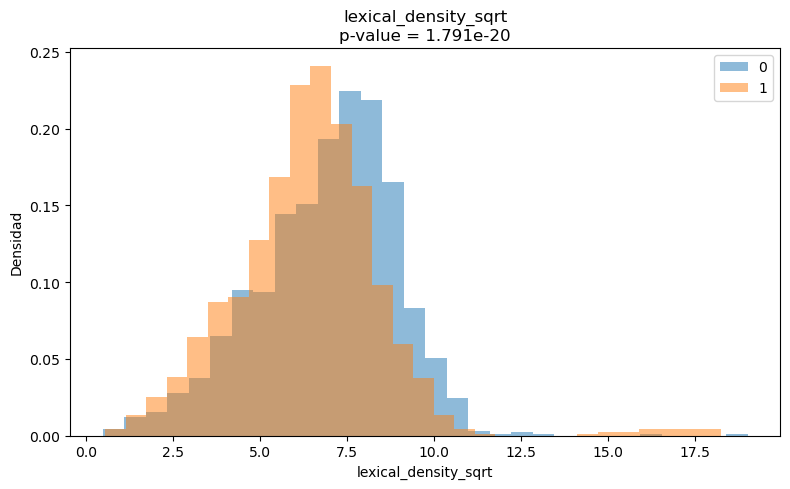

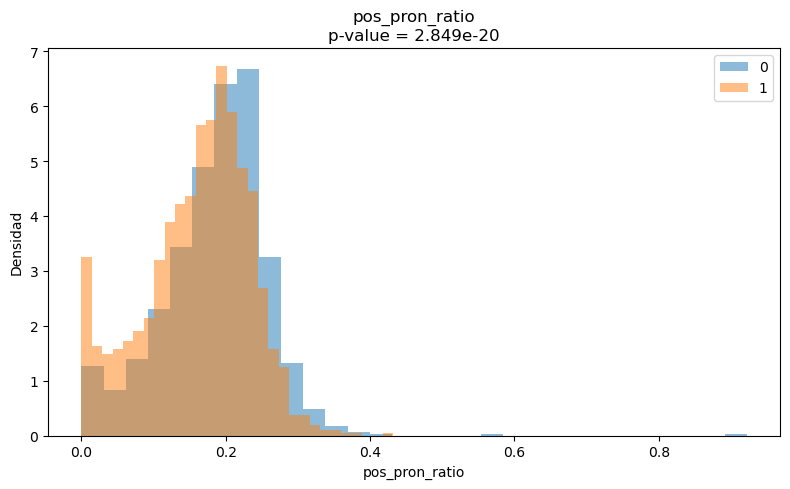

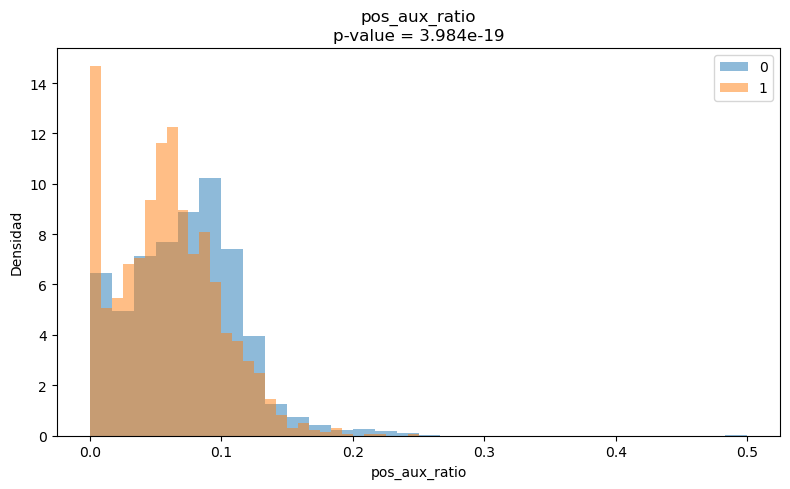

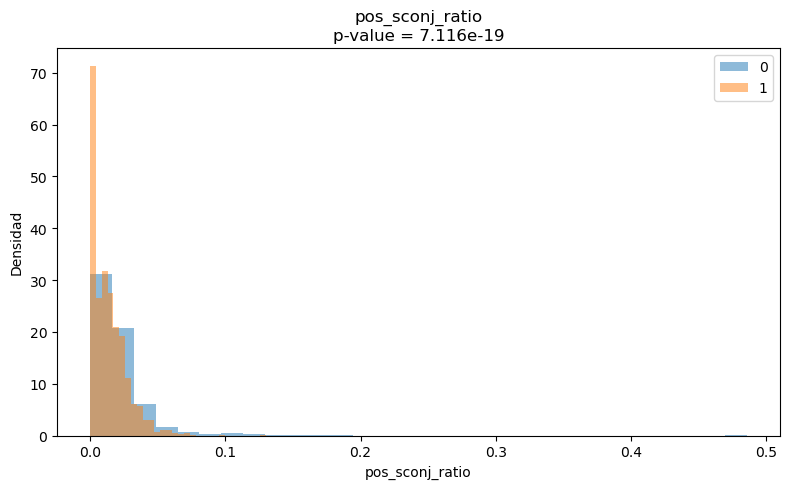

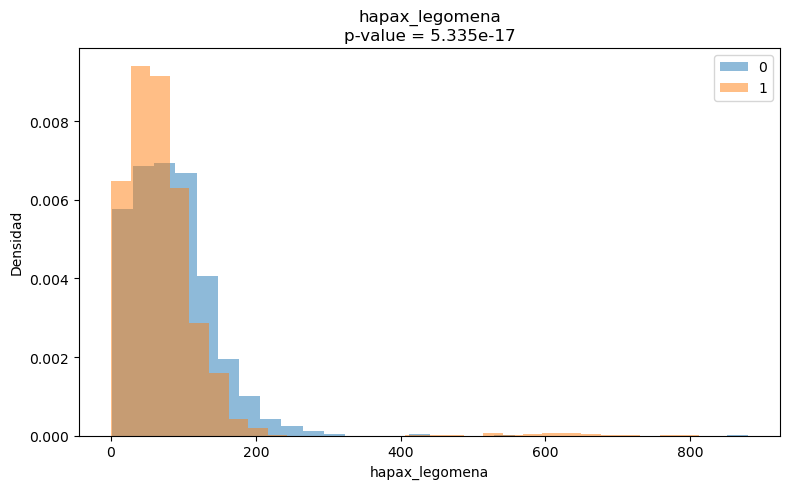

In [73]:

# Número de variables a graficar
n_top = 5

# Seleccionar las n variables con menor p-value
top_variables = df_significancia["variable"].head(n_top).tolist()

# Obtener los dos grupos
niveles = df["target"].dropna().unique()
if len(niveles) != 2:
    raise ValueError("La columna 'target' debe contener exactamente dos grupos.")

grupo_a, grupo_b = niveles

# Crear una figura por cada variable
for col in top_variables:
    # Preparar datos sin valores faltantes
    datos = df_stats[[col]].join(df["target"]).dropna()

    x = datos.loc[datos["target"] == grupo_a, col]
    y = datos.loc[datos["target"] == grupo_b, col]

    # Graficar histogramas superpuestos
    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=30, alpha=0.5, density=True, label=str(grupo_a))
    plt.hist(y, bins=30, alpha=0.5, density=True, label=str(grupo_b))

    # Añadir información de significancia al título
    p_value = df_significancia.loc[
        df_significancia["variable"] == col, "p_value"
    ].iloc[0]

    plt.title(f"{col}\np-value = {p_value:.4g}")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Usar el dashboard

In [80]:
df_stats.to_pickle("df_stats.pkl")
df.to_pickle("df.pkl")
df_significancia.to_pickle("df_significancia.pkl")

### Modelo predictivo

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Usar el dataset balanceado previamente creado
# ------------------------------------------------------------
# Se asume que ya existe el DataFrame `data_balanced`

# Columnas a excluir
exclude_cols = [
    'file_name',
    'file_path',
    'disorder_code',
    'disorder_label',
    'group'
]

# Seleccionar features numéricas
feature_cols = [
    col for col in data_balanced.select_dtypes(include='number').columns
    if col not in exclude_cols
]

# Eliminar filas con valores faltantes
model_data = data_balanced.dropna(
    subset=feature_cols + ['group']
).copy()

# Variables predictoras y objetivo
X = model_data[feature_cols]
y = model_data['group']

# ------------------------------------------------------------
# 2. División entrenamiento/prueba (estratificada)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 3. Entrenar Random Forest
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Predicciones
# ------------------------------------------------------------
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

# ------------------------------------------------------------
# 5. Evaluación del modelo
# ------------------------------------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# ROC-AUC para clasificación binaria
if len(rf.classes_) == 2:
    # Tomar la probabilidad de la segunda clase
    auc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC:", auc)

# ------------------------------------------------------------
# 6. Importancia de variables
# ------------------------------------------------------------
feature_importance = (
    pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 variables más importantes:")
print(feature_importance.head(20))

# ------------------------------------------------------------
# 7. Comparar con variables significativas (Mann-Whitney)
# ------------------------------------------------------------
if 'significant_features_balanced' in globals():
    significant_set = set(significant_features_balanced['feature'])

    feature_importance['significant_mannwhitney'] = (
        feature_importance['feature'].isin(significant_set)
    )

    print("\nVariables importantes que también fueron significativas:")
    print(
        feature_importance[
            feature_importance['significant_mannwhitney']
        ].head(20)
    )

# Si deseas guardar:
# feature_importance.to_csv(
#     "random_forest_feature_importance_balanced.csv",
#     index=False
# )

Accuracy: 0.7533333333333333
Balanced Accuracy: 0.7533333333333333

Matriz de confusión:
[[229  71]
 [ 77 223]]

Reporte de clasificación:
              precision    recall  f1-score   support

     control       0.75      0.76      0.76       300
experimental       0.76      0.74      0.75       300

    accuracy                           0.75       600
   macro avg       0.75      0.75      0.75       600
weighted avg       0.75      0.75      0.75       600

ROC-AUC: 0.8339333333333334

Top 20 variables más importantes:
                           feature  importance
0                  pos_propn_ratio    0.032905
1                common_word_ratio    0.030684
2                   pos_intj_ratio    0.029167
3         tfidf_adjacent_coherence    0.028860
4                    pos_det_ratio    0.025924
5                   pos_pron_ratio    0.025846
6             lexical_density_sqrt    0.025242
7          tfidf_centroid_distance    0.025179
8                    pos_aux_ratio    0.024882
9